# Metody i narzędzia Big Data 2:
### US Domestic Flights Delay Prediction (2013 - 2018)

### Import bibliotek i przygotowanie do pr*cy
W komentarzach znajdują się fragmenty poleceń w pdf dostarczonym do projektu realizowanych przez dany fragment kodu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('flight_delay_predict.csv')

# Wczytaj dane, a następnie podaj liczbę wszystkich rekordów


In [2]:
print(df.count())

is_delay             1635590
Year                 1635590
Quarter              1635590
Month                1635590
DayofMonth           1635590
DayOfWeek            1635590
FlightDate           1635590
Reporting_Airline    1635590
Origin               1635590
OriginState          1635590
Dest                 1635590
DestState            1635590
CRSDepTime           1635590
Cancelled            1635590
Diverted             1635590
Distance             1635590
DistanceGroup        1635590
ArrDelay             1635590
ArrDelayMinutes      1635590
AirTime              1635590
dtype: int64


1_635_590 rekordów

# Analiza linii lotniczych

### a) Wyznacz średnie opóźnienie dla każdej linii lotniczej
(zakładam że opóźnienie dotyczy tylko przylotów PO czasie, a nie również ArrDelay z wartościami ujemnymi lub ich brak)

In [3]:
print(df[df['ArrDelayMinutes']>0]
      .groupby('Reporting_Airline')['ArrDelayMinutes']
      .mean()
      .round(2))

Reporting_Airline
AA    34.27
DL    34.47
OO    38.52
UA    37.47
WN    32.36
Name: ArrDelayMinutes, dtype: float64


### b) Oblicz procent opóźnionych lotów (dla każdej linii)

In [4]:
delay_percentages=(df[df['ArrDelayMinutes']>0].groupby('Reporting_Airline')['ArrDelayMinutes']
                   .count()
                   /
                   df.groupby('Reporting_Airline')['ArrDelayMinutes']
                   .count()
                   ).sort_values(ascending=True)
d_p_dict=delay_percentages.to_dict()
for key,val in d_p_dict.items():
    print(key,': ', f"{val:.2%}", sep="")

DL: 32.37%
UA: 37.49%
AA: 39.27%
OO: 44.72%
WN: 48.24%


### c) Wyznacz ranking linii lotniczych (zwizualizuj również za pomocą wykresu)

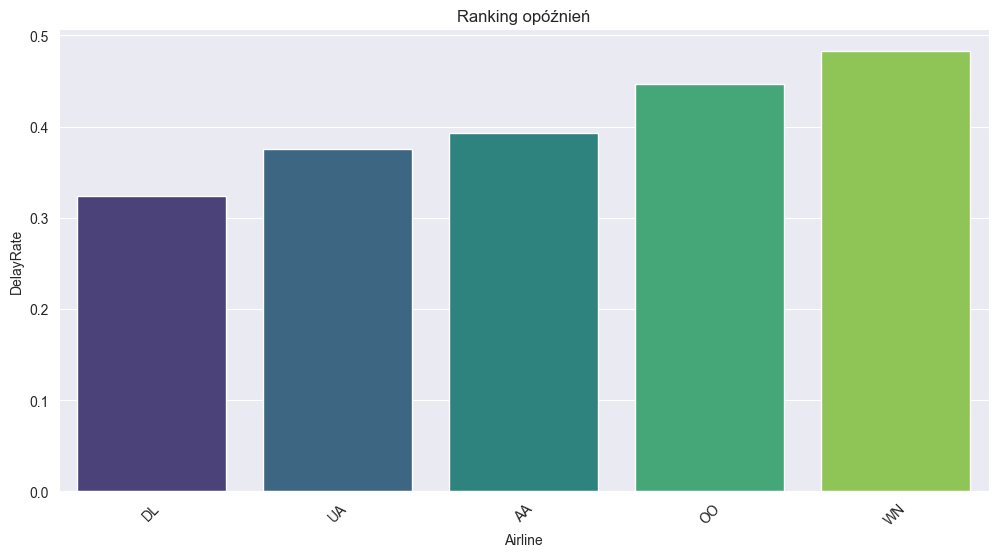

In [5]:
data_to_plot = delay_percentages.reset_index()
data_to_plot.columns = ['Airline', 'DelayRate']

plt.figure(figsize=(12, 6))
sns.barplot(x='Airline', y='DelayRate', data=data_to_plot, palette='viridis', hue='Airline')

plt.title('Ranking opóźnień')
plt.xticks(rotation=45)
plt.show()

# Analiza lotnisk

### a) Zidentyfikuj lotniska generujące największe opóźnienia

In [6]:
airport_delays=(df[df['ArrDelayMinutes']>0].groupby('Origin')['ArrDelayMinutes']
                .agg(['mean', 'max'])
                .sort_values(by='mean', ascending=False)
                .round(2))

print(airport_delays.head())

         mean     max
Origin               
ORD     39.42  1203.0
IAH     37.78  1555.0
DFW     36.70  1400.0
SFO     35.80  2142.0
DEN     35.78  1505.0


### b) Wyznacz średnie opóźnienie dla lotnisk wylotu

In [7]:
airport_delays=((df.groupby('Origin')['ArrDelayMinutes'])
                .mean()
                .round(2))

print(airport_delays.head(airport_delays.count()))

Origin
ATL    11.27
CLT    12.08
DEN    13.76
DFW    14.64
IAH    14.01
LAX    13.38
ORD    16.52
PHX    11.67
SFO    14.79
Name: ArrDelayMinutes, dtype: float64


### c) Wypisz 10 najgorszych lotnisk (pod względem opóźnień, przedstaw także za pomocą wykresu)

Origin
ORD    16.52
SFO    14.79
DFW    14.64
IAH    14.01
DEN    13.76
LAX    13.38
CLT    12.08
PHX    11.67
ATL    11.27
Name: ArrDelayMinutes, dtype: float64


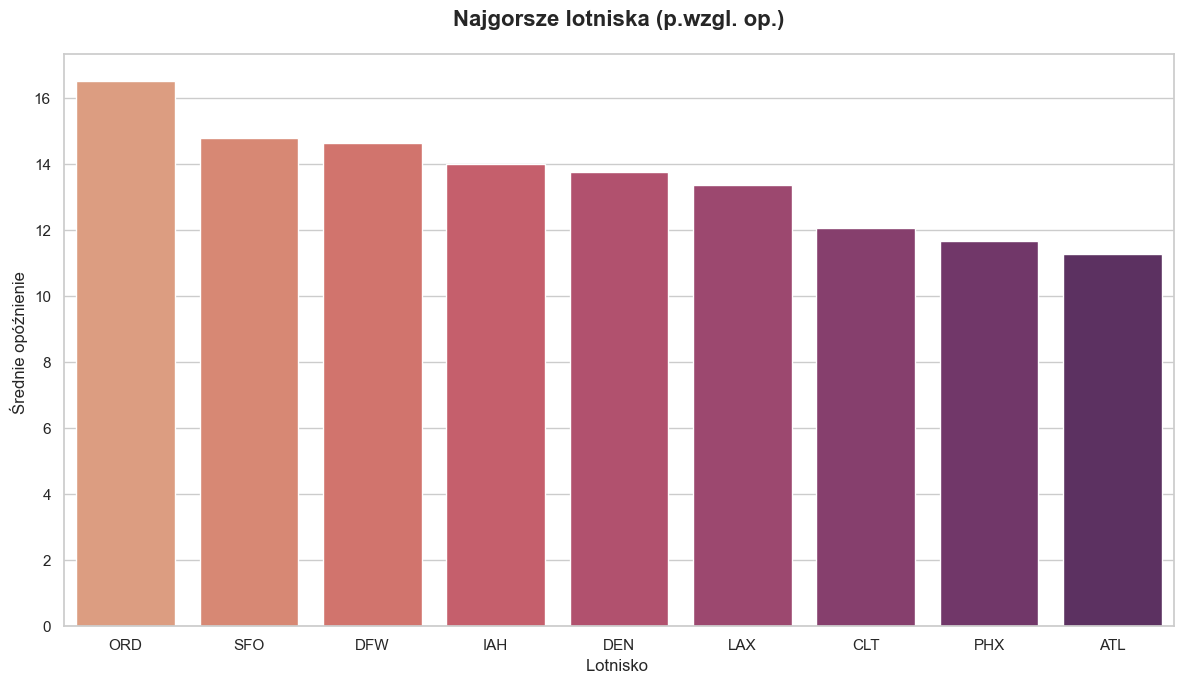

In [8]:
print(airport_delays.sort_values(ascending=False))

data_to_plot = airport_delays.reset_index()
data_to_plot.columns=['Origin', 'mean']
data_to_plot=data_to_plot.sort_values('mean', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

barplot = sns.barplot(
    x='Origin',
    y='mean',
    data=data_to_plot,
    hue='Origin',
    palette='flare',
    legend=False
)


plt.title('Najgorsze lotniska (p.wzgl. op.)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Lotnisko ', fontsize=12)
plt.ylabel('Średnie opóźnienie ', fontsize=12)

plt.tight_layout()
plt.show()

# Analiza sezonowości

### a) Porównaj opóźnienia w różnych miesiącach (można uśrednić dla wszystkich linii lotniczych)

In [9]:
monthly_delays=(df.groupby(['Month'])['ArrDelayMinutes']
                .mean()
                .round(2))

print(monthly_delays.head(12))

Month
1     13.37
2     12.57
3     12.55
4     12.53
5     14.64
6     18.04
7     16.46
8     16.41
9     10.40
10    11.38
11    10.75
12    14.98
Name: ArrDelayMinutes, dtype: float64


### b) Zidentyfikuj okresy z największymi opóźnieniami
Od maja do sierpnia (5- 8) z dodatkiem grudnia

Od przypadku jeżeli chodzi o kwartały:

In [10]:
quarterly_delays=(df.groupby(['Quarter'])['ArrDelayMinutes']
                  .mean()
                  .round(2))
print(quarterly_delays.head())

Quarter
1    12.83
2    15.10
3    14.52
4    12.36
Name: ArrDelayMinutes, dtype: float64


# Analiza odległości

### a) Zbadaj zależność między odległością lotu a opóźnieniem (np. czy dłuższy/krótszy lot powoduje mniejsze/większe opóźnienie, itp)

In [16]:
correlation = df['Distance'].corr(df['ArrDelayMinutes'])

print(f"Korelacja Distance-ArrDelayMinutes: {correlation}")

Korelacja Distance-ArrDelayMinutes: -0.013593812569450654


### b) Zwizualizuj tę zależność (np. wykres punktowy)

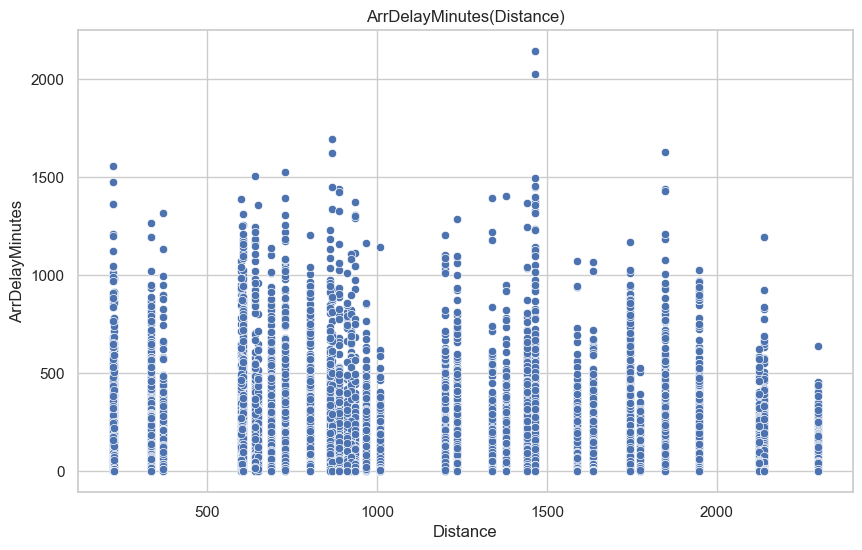

In [17]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Distance', y='ArrDelayMinutes')

plt.title('ArrDelayMinutes(Distance)')
plt.xlabel('Distance')
plt.ylabel('ArrDelayMinutes')

plt.show()

Zarówno korelacja jak i wykres wskazują na brak zależności między opóźnieniem i dystansem.

# Analiza anulowanych i przekierowanych lotów